In [9]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from astropy.io import fits
from scipy.ndimage import gaussian_filter
import pandas as pd
from tqdm.notebook import trange, tqdm

In [10]:
#Fase caricamento dati in x e y
hdulist = fits.open('data_cubet.fits')
#estraggo data_cube
datcube = hdulist[0].data #immagini
X = datcube[:, 1, :, :] #mappa vel
dataset = pd.read_excel('dataset.xlsx') #etichette
y=dataset.beta
hdulist.close()
print(y)
X.shape
nan_indices = np.isnan(X)
X[nan_indices] = 0

0       10.769688
1       22.777596
2       44.954512
3       35.922824
4       50.471792
          ...    
9995    54.743283
9996    74.899036
9997    45.336093
9998    84.299578
9999    77.294848
Name: beta, Length: 10000, dtype: float64


In [11]:
#Fase suddivisione dati
from sklearn.model_selection import train_test_split

#X_max=np.nanmax(np.abs(X), axis=(1,2))
#X_norm= X/X_max[:,None,None]
#y_norm= y/X_max

X_max=1
X_norm= X/X_max
y_norm= y/X_max

#uso la funzione train_test_split per suddividere i dati in un set di addestramento (training set 70%) e un set di test (test set 30%)
X_train, X_split, y_train, y_split = train_test_split(X_norm, y_norm, test_size=0.3, random_state=42, shuffle=True) #random_state per la riproducibilità, e shuffle per mescolamento dati
#suddivido set di test in validazione (66,6%) e test (33,3%)
X_valid, X_test, y_valid, y_test = train_test_split(X_split, y_split, test_size=0.666, random_state=42, shuffle=True)


In [12]:
#ridimensiono sia array di X test che valid che addestr in un formato che rappresenta le immagini in array tridimensionali
imsize = np.shape(X_train)[2]
X_train = X_train.reshape(-1, imsize, imsize, 1) #-1 cioè tutte le immagini, 3 cioè i canali (le 3 mappe)
X_valid = X_valid.reshape(-1, imsize, imsize, 1)
X_test = X_test.reshape(-1, imsize, imsize, 1)
X_test.shape
print(X_test.shape)
X_train.shape
print(X_train.shape)
X_valid.shape
print(X_valid.shape)

(1998, 81, 81, 1)
(7000, 81, 81, 1)
(1002, 81, 81, 1)


In [15]:
#costruzione modello
import tensorflow.compat.v1 as tf
from keras.models import Sequential
from keras.layers import Dense, Dropout, Flatten, BatchNormalization
from keras.layers import Conv2D, MaxPooling2D
from keras.utils import to_categorical
from keras.preprocessing import image

#utilizzo architettura VGGnet
def Model_gal2(input_shape=(imsize,imsize, 1), learning_rate=0.001):
    model = Sequential()
    model.add(Conv2D(16, kernel_size=(3,3),activation='relu', input_shape=input_shape,  name='conv1')) #strato conv con 32 nodi di output, prende immagini in input e inizia elaborazione
    model.add(Conv2D(16, (3, 3), activation='relu', name='conv2'))
    model.add(MaxPooling2D(pool_size=(2, 2))) #riduce dimensioni spaziali dell'output precedente, estrae caratteristiche piu' importanti tramite il max nell'area in cui è applicato il filtro
    #model.add(Dropout(0.25)) # probabilità del 25% di azzerare connessioni durante addestramento (previene overfitting)

    model.add(Conv2D(32, (3, 3), activation='relu', name='conv3'))
    model.add(Conv2D(32, (3, 3), activation='relu', name='conv4'))
    model.add(MaxPooling2D(pool_size=(2, 2)))
    model.add(Conv2D(64, (3, 3), activation='relu', name='conv5'))
    model.add(Conv2D(64, (3, 3), activation='relu', name='conv6'))
   # model.add(BatchNormalization(axis = 3, name = 'bn')) #l'asse=3 specifica l'asse lungo il quale viene applicata la normalizzazione (per migliorare stabilità dell'addestramento), nel nostro caso al canale(che è 3) e quindi la normalizzazione è applicata a ciascuna mappa separatamente
    model.add(MaxPooling2D(pool_size=(2, 2)))
    #model.add(Dropout(0.25))#aumento prob a 50%

    model.add(Flatten()) #trasfroma output precedente da 2D a 1D
    model.add(Dense(128, activation='relu', name='den1'))
    #model.add(Dense(32, activation='relu', name='den2'))
    #model.add(Dense(8, activation='relu', name='den3'))

    model.add(Dense(1, activation='linear', name='fc_out'))# genera l'output finale, che rappresenta la previsione numerica , NB non so quale funzione di attivazione usare
    model.summary()
    #Fase compilazione
    model.compile(loss='mse', optimizer=tf.keras.optimizers.Adam(learning_rate), metrics=['mse', 'mae']) #adam attua automaticamente il tasso di apprensimento durante l'addestramento
#si usa mse per prevedere un valore numerico anziché classificare in categorie, misura la media dei quadrati delle differenze tra le previsioni del modello e i valori di target reali.
#mae calcola la media delle differenze assolute tra le previsioni del modello e i valori di target reali
    return model

In [16]:
model = Model_gal2()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape              ┃    Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━┩
│ conv1 (Conv2D)                  │ (None, 79, 79, 16)        │        160 │
├─────────────────────────────────┼───────────────────────────┼────────────┤
│ conv2 (Conv2D)                  │ (None, 77, 77, 16)        │      2,320 │
├─────────────────────────────────┼───────────────────────────┼────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 38, 38, 16)        │          0 │
├─────────────────────────────────┼───────────────────────────┼────────────┤
│ conv3 (Conv2D)                  │ (None, 36, 36, 32)        │      4,640 │
├─────────────────────────────────┼───────────────────────────┼────────────┤
│ conv4 (Conv2D)                  │ (None, 34, 34, 32)        │      9,248 │
├─────────────────────────────────┼───────────────────────────┼────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 17, 17, 32)        │          0 │
├─────────────────────────────────┼───────────────────────────┼────────────┤
│ conv5 (Conv2D)                  │ (None, 15, 15, 64)        │     18,496 │
├─────────────────────────────────┼───────────────────────────┼────────────┤
│ conv6 (Conv2D)                  │ (None, 13, 13, 64)        │     36,928 │
├─────────────────────────────────┼───────────────────────────┼────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 6, 6, 64)          │          0 │
├─────────────────────────────────┼───────────────────────────┼────────────┤
│ flatten (Flatten)               │ (None, 2304)              │          0 │
├─────────────────────────────────┼───────────────────────────┼────────────┤
│ den1 (Dense)                    │ (None, 128)               │    295,040 │
├─────────────────────────────────┼───────────────────────────┼────────────┤
│ fc_out (Dense)                  │ (None, 1)                 │        129 │
└─────────────────────────────────┴───────────────────────────┴────────────┘

 Total params: 366,961 (1.40 MB)

 Trainable params: 366,961 (1.40 MB)

 Non-trainable params: 0 (0.00 B)

In [17]:
history=model.fit(X_train, y_train, validation_data=(X_valid, y_valid), epochs=100,batch_size=128)

Epoch 1/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 16s 258ms/step - loss: 1467.4175 - mae: 29.4151 - mse: 1467.5140 - val_loss: 497.5724 - val_mae: 17.4727 - val_mse: 497.6257
Epoch 2/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 16s 287ms/step - loss: 446.3316 - mae: 16.3226 - mse: 446.3401 - val_loss: 406.0011 - val_mae: 15.4624 - val_mse: 405.5543
Epoch 3/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 16s 284ms/step - loss: 347.7935 - mae: 14.4367 - mse: 347.8053 - val_loss: 334.9486 - val_mae: 14.2853 - val_mse: 334.3823
Epoch 4/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 16s 289ms/step - loss: 277.5096 - mae: 13.3387 - mse: 277.5217 - val_loss: 277.2043 - val_mae: 13.9664 - val_mse: 277.4026
Epoch 5/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 16s 294ms/step - loss: 250.4665 - mae: 12.7203 - mse: 250.4699 - val_loss: 232.7190 - val_mae: 12.4947 - val_mse: 232.8329
Epoch 6/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 16s 294ms/step - loss: 218.8820 - mae: 11.9175 - mse: 218.8815 - val_loss: 233.7891 - val_mae: 12.0297 - val_mse: 233.7288
Epoch 7/100
55/55 ━━━━━━━━

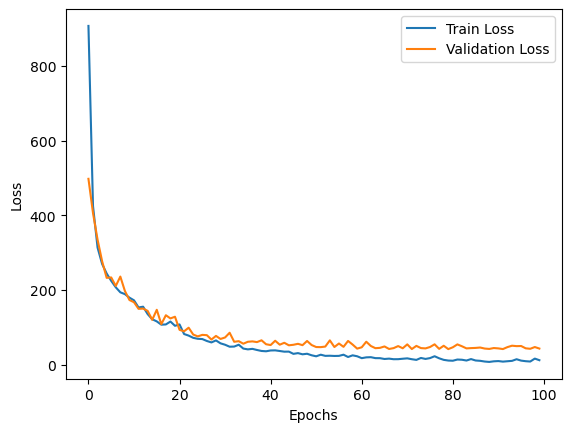

In [18]:
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()


In [19]:
y_test_pred=model.predict(X_test)

63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 38ms/step


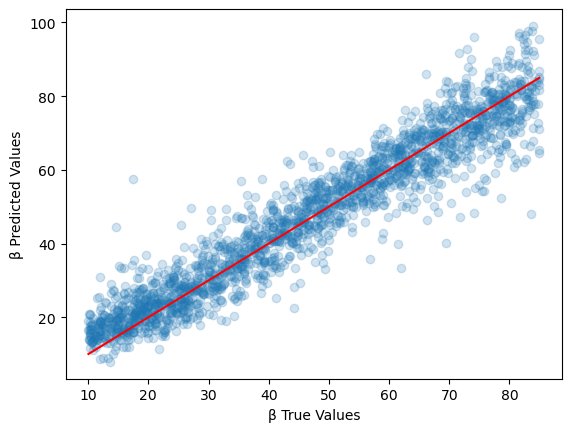

In [20]:
plt.scatter(y_test, y_test_pred, label='Test Data', alpha=0.2 )

plt.xlabel('β True Values')
plt.ylabel('β Predicted Values')
plt.plot([y_test.min(),y_test.max()],[y_test.min(),y_test.max()], color='red')

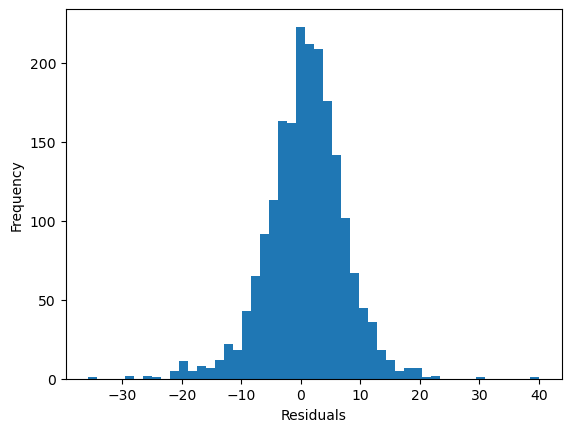

In [21]:
#calcolo residui
y_test_pred = y_test_pred.ravel()
residuals = y_test_pred - y_test
plt.hist(residuals, bins=50)
plt.xlabel('Residuals')
plt.ylabel('Frequency')
plt.show()

In [22]:
#calcolo deviazione standard  dei residui con RMSE
std_deviation = np.std(residuals)
rmse = np.sqrt(np.mean(residuals**2))
print('std_deviation:',std_deviation)
print('rmse:',rmse)


std_deviation: 6.5824540373693745
rmse: 6.624669705441934


In [23]:
file_path = r"C:\Users\39351\Downloads\maps 2\UGC731\UGC731map_1st.fits"

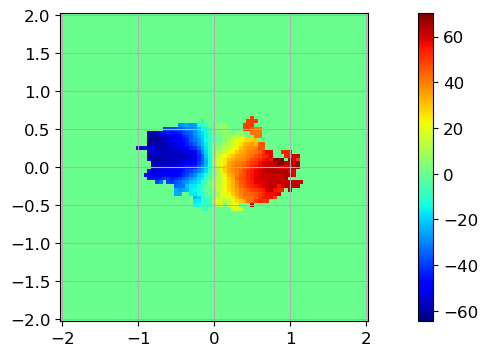

In [24]:
hdulist = fits.open(file_path)
X_vera = hdulist[0].data
nan_indices = np.isnan(X_vera)
X_vera[nan_indices] = 0
plt.rcParams['figure.figsize'] = [16, 4]
plt.rcParams['figure.dpi']= 100 # set plot image resolution (dpi)
plt.rcParams.update({'font.size': 12})

fig, ax1 = plt.subplots(1)
def vmin(array):
    return np.abs(np.nanpercentile(array, 5))
def vmax(array):
    return np.nanpercentile(array, 95)
extent = [-2.025, 2.025, -2.025, 2.025]
#plt.imshow(hdu_data, origin='lower', cmap='jet')
cset1 = ax1.imshow(X_vera, origin='lower',  extent=extent, cmap='jet') #vmin=vmin(map_flux), vmax=vmax(map_flux), cmap='jet')
ax1.grid()
fig.colorbar(cset1, fraction=0.046, pad=0.04, ax=ax1)
plt.show()


In [25]:
# Aggiungi una dimensione per il batch
X_vera_1= np.expand_dims(X_vera, axis=0)

# Aggiungi una dimensione per il canale
X_vera_final = np.expand_dims(X_vera_1, axis=-1)
print(X_vera_final.shape)
y_test_pred=model.predict(X_vera_final)

(1, 81, 81, 1)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step


In [26]:
print(y_test_pred)

[[55.46211]]


In [27]:
file_path = r"C:\Users\39351\Downloads\maps\ALESS73.1\ALESS73.1map_1st.fits"

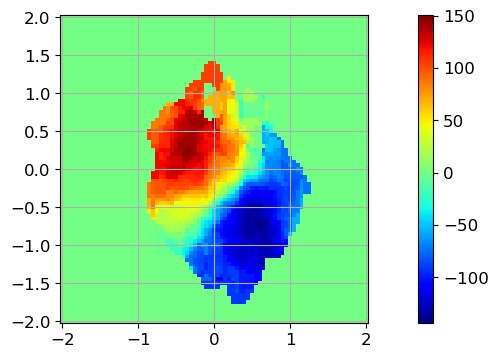

In [28]:
hdulist = fits.open(file_path)
X_vera = hdulist[0].data
nan_indices = np.isnan(X_vera)
X_vera[nan_indices] = 0
plt.rcParams['figure.figsize'] = [16, 4]
plt.rcParams['figure.dpi']= 100 # set plot image resolution (dpi)
plt.rcParams.update({'font.size': 12})

fig, ax1 = plt.subplots(1)
def vmin(array):
    return np.abs(np.nanpercentile(array, 5))
def vmax(array):
    return np.nanpercentile(array, 95)
extent = [-2.025, 2.025, -2.025, 2.025]
#plt.imshow(hdu_data, origin='lower', cmap='jet')
cset1 = ax1.imshow(X_vera, origin='lower',  extent=extent, cmap='jet') #vmin=vmin(map_flux), vmax=vmax(map_flux), cmap='jet')
ax1.grid()
fig.colorbar(cset1, fraction=0.046, pad=0.04, ax=ax1)
plt.show()

In [29]:
# Aggiungi una dimensione per il batch
X_vera_1= np.expand_dims(X_vera, axis=0)

# Aggiungi una dimensione per il canale
X_vera_final = np.expand_dims(X_vera_1, axis=-1)
print(X_vera_final.shape)
y_test_pred=model.predict(X_vera_final)

(1, 81, 81, 1)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step


In [30]:
print(y_test_pred)

[[51.62466]]
